In [15]:
import pandas as pd
import seaborn as sns
import numpy as np #Was used for computing averages
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})


In [16]:
# Loading the datasets
pop = pd.read_csv("population.csv")
exp = pd.read_csv("life_expectancy.csv")
gni = pd.read_csv("gni_per_cap_atlas_method_con2021.csv")

In [17]:
#Melting arond the country column
pop = pop.melt(id_vars = 'country')
exp = exp.melt(id_vars = 'country')
gni = gni.melt(id_vars = 'country')


In [18]:
# Merging around country and year

merged_df = pd.merge(pop, exp, on=['country', 'variable'], how='inner')

Merged_df = pd.merge(merged_df, gni, on=['country', 'variable'], how = 'inner')


In [19]:
# Renaming the columns of the merged dataframe
Merged_df.columns = ['country', 'year', 'population', 'life_expectancy', 'gni']
Merged_df

,country,year,population,life_expectancy,gni
0,Afghanistan,1800,3.28M,28.2,207.0
1,Angola,1800,1.57M,27.0,517.0
2,Albania,1800,400k,35.4,207.0
3,United Arab Emirates,1800,40.2k,30.7,738.0
4,Argentina,1800,534k,33.2,794.0
...,...,...,...,...,...
47685,Samoa,2050,320k,74.3,6440
47686,Yemen,2050,55.3M,72.2,1730
47687,South Africa,2050,73.5M,70.9,9220
47688,Zambia,2050,37.5M,69.8,1520


In [20]:
## Cleaning

Merged_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 47690 entries, 0 to 47689
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   country          47690 non-null  str    
 1   year             47690 non-null  str    
 2   population       47690 non-null  str    
 3   life_expectancy  46604 non-null  float64
 4   gni              47690 non-null  object 
dtypes: float64(1), object(1), str(3)
memory usage: 1.8+ MB


In [21]:
#Converting year type to float
Merged_df = Merged_df.astype({'year': float })
Merged_df.dtypes

country                str
year               float64
population             str
life_expectancy    float64
gni                 object
dtype: object

In [22]:
#Removing non-numbers from the population column, and converting it to float
# Converting the population column to float

def clean_pop(val):
    if pd.isna(val) or val == '':
        return 0
    
    val = str(val).lower().strip()
    multipliers = {'k': 1000, 'm': 1000000}
    
    if val[-1] in multipliers:
        suffix = val[-1]
        try:
            return float(val[:-1]) * multipliers[suffix]
        except ValueError:
            return 0 # Or handle as needed
    
    try:
        return float(val)
    except ValueError:
        return 0

# Apply to your specific dataframe and column
Merged_df['population'] = Merged_df['population'].apply(clean_pop)

In [23]:
# Converting the gni column to float

def clean_pop(val):
    if pd.isna(val) or val == '':
        return 0
    
    val = str(val).lower().strip()
    multipliers = {'k': 1000, 'm': 1000000}
    
    if val[-1] in multipliers:
        suffix = val[-1]
        try:
            return float(val[:-1]) * multipliers[suffix]
        except ValueError:
            return 0 # Or handle as needed
    
    try:
        return float(val)
    except ValueError:
        return 0

# Apply to your specific dataframe and column
Merged_df['gni'] = Merged_df['gni'].apply(clean_pop)

In [24]:
# Checking for null values
Merged_df.isnull().sum()

country               0
year                  0
population            0
life_expectancy    1086
gni                   0
dtype: int64

In [25]:
missing_data_df = Merged_df[Merged_df['life_expectancy'].isnull()]
countries_with_nulls = missing_data_df['country'].unique()
countries_with_nulls

<StringArray>
[           'Dominica', 'St. Kitts and Nevis',    'Marshall Islands',
               'Nauru',               'Palau',              'Tuvalu']
Length: 6, dtype: str

In [26]:
# Removing the countries wtih missing data from the dataset

countries_to_remove = [
    'Dominica', 'St. Kitts and Nevis', 'Marshall Islands', 
    'Nauru', 'Palau', 'Tuvalu'
]
df_clean = Merged_df[~Merged_df['country'].isin(countries_to_remove)]


In [27]:
df_clean.isnull().sum()

country            0
year               0
population         0
life_expectancy    0
gni                0
dtype: int64

In [28]:
# Removing all years except those from 1990 to 2025
df_clean = df_clean[(df_clean['year'] >= 1990) & (df_clean['year'] <= 2025)]

In [29]:
df_clean

,country,year,population,life_expectancy,gni
36100,Afghanistan,1990.0,10700000.0,53.8,340.0
36101,Angola,1990.0,11800000.0,49.7,1410.0
36102,Albania,1990.0,3300000.0,72.8,1180.0
36103,United Arab Emirates,1990.0,1900000.0,68.7,33800.0
36104,Argentina,1990.0,32600000.0,72.5,5770.0
...,...,...,...,...,...
42935,Samoa,2025.0,232000.0,71.2,3970.0
42936,Yemen,2025.0,36000000.0,68.4,969.0
42937,South Africa,2025.0,61700000.0,66.5,6100.0
42938,Zambia,2025.0,21700000.0,64.7,1060.0


In [30]:
def classify_income(gni):
    """World Bank Atlas Method thresholds (2025 USD)."""
    if pd.isna(gni):
        return 'Unknown'
    if gni < 1_085:     return 'Low Income'
    if gni < 4_255:     return 'Lower-Middle Income'
    if gni < 13_205:    return 'Upper-Middle Income'
    return 'High Income'

df_clean['income_group'] = df_clean['gni'].apply(classify_income)

# Overview for 2025
print("Income group distribution (2025):")
dist = df_clean[df_clean.year==2025]['income_group'].value_counts()
print(dist.to_string())

Income group distribution (2025):
income_group
High Income            55
Lower-Middle Income    54
Upper-Middle Income    52
Low Income             23


In [31]:
df_clean

,country,year,population,life_expectancy,gni,income_group
36100,Afghanistan,1990.0,10700000.0,53.8,340.0,Low Income
36101,Angola,1990.0,11800000.0,49.7,1410.0,Lower-Middle Income
36102,Albania,1990.0,3300000.0,72.8,1180.0,Lower-Middle Income
36103,United Arab Emirates,1990.0,1900000.0,68.7,33800.0,High Income
36104,Argentina,1990.0,32600000.0,72.5,5770.0,Upper-Middle Income
...,...,...,...,...,...,...
42935,Samoa,2025.0,232000.0,71.2,3970.0,Lower-Middle Income
42936,Yemen,2025.0,36000000.0,68.4,969.0,Low Income
42937,South Africa,2025.0,61700000.0,66.5,6100.0,Upper-Middle Income
42938,Zambia,2025.0,21700000.0,64.7,1060.0,Low Income


In [33]:
#Finding the global life expectancy each year
def weighted_le(group):
    """Population-weighted average life expectancy."""
    w = group['population'].fillna(1)
    return np.average(group['life_expectancy'], weights=w)

global_le = df_clean.groupby('year').apply(weighted_le)


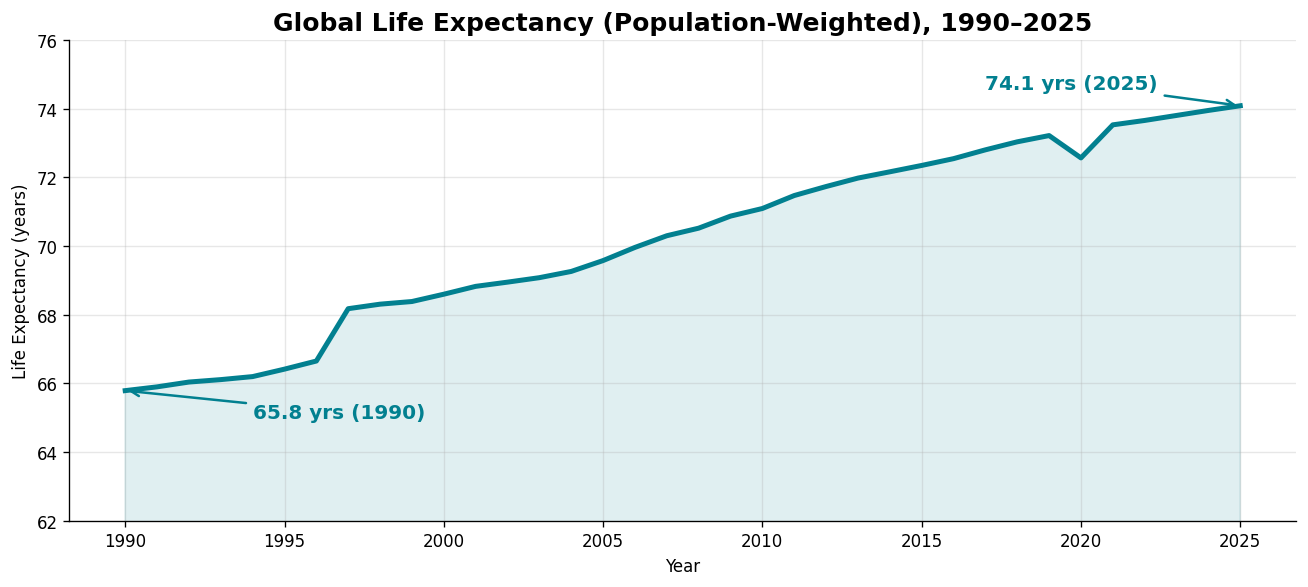

Total global gain: +8.3 years


In [34]:
# Plotting the gni and life expectancy relation from 1990 to 2025, used AI for visual

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(global_le.index, global_le.values, color='#028090', linewidth=3)
ax.fill_between(global_le.index, global_le.values, alpha=0.12, color='#028090')

le90, le25 = global_le.loc[1990], global_le.loc[2025]
ax.annotate(f'{le90:.1f} yrs (1990)', xy=(1990, le90), xytext=(1994, le90-0.8),
            fontsize=12, color='#028090', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#028090', lw=1.5))
ax.annotate(f'{le25:.1f} yrs (2025)', xy=(2025, le25), xytext=(2017, le25+0.5),
            fontsize=12, color='#028090', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#028090', lw=1.5))

ax.set_title('Global Life Expectancy (Population-Weighted), 1990–2025', fontsize=15, fontweight='bold')
ax.set_xlabel('Year'); ax.set_ylabel('Life Expectancy (years)')
ax.set_ylim(62, 76)
plt.tight_layout();
plt.savefig('Global_Life_Expectancy.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Total global gain: +{le25-le90:.1f} years")

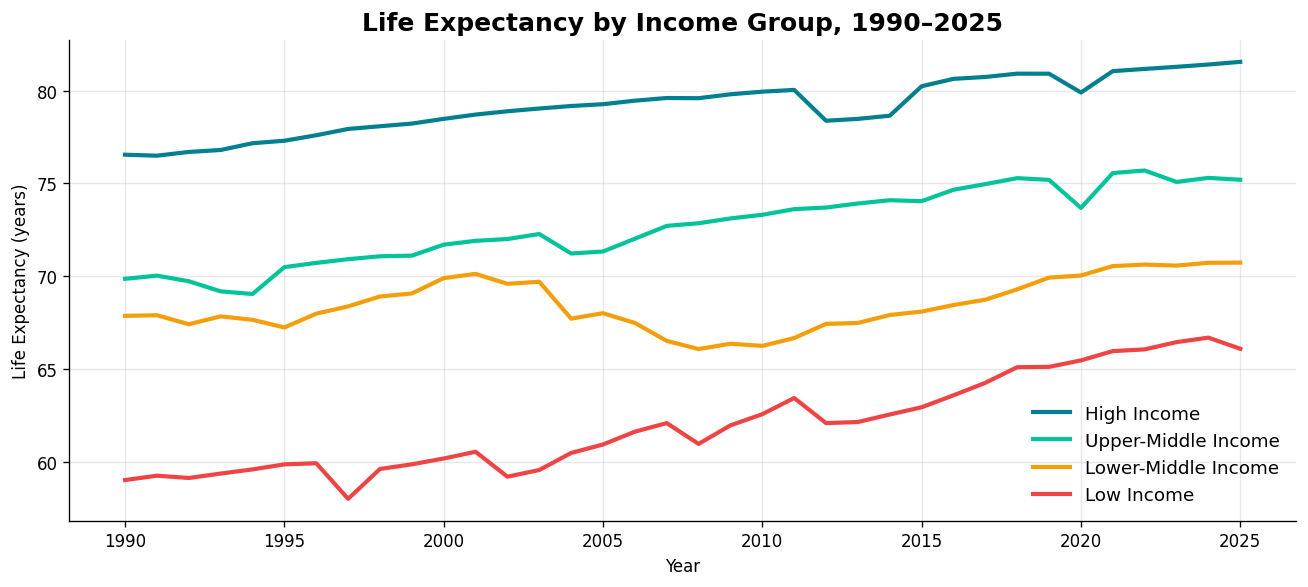

In [35]:
# Plotting the gni and life expectancy relation per income group from 1990 to 2025, used AI for visual

INCOME_ORDER = ['High Income', 'Upper-Middle Income', 'Lower-Middle Income', 'Low Income']
COLORS = {
    'High Income': '#028090',
    'Upper-Middle Income': '#02C39A',
    'Lower-Middle Income': '#F59E0B',
    'Low Income': '#EF4444'
}

fig, ax = plt.subplots(figsize=(11, 5))
for ig in INCOME_ORDER:
    s = df_clean[df_clean.income_group==ig].groupby('year').apply(weighted_le)
    ax.plot(s.index, s.values, color=COLORS[ig], linewidth=2.5, label=ig)

ax.set_title('Life Expectancy by Income Group, 1990–2025', fontsize=15, fontweight='bold')
ax.set_xlabel('Year'); ax.set_ylabel('Life Expectancy (years)')
ax.legend(frameon=False, fontsize=11)
plt.tight_layout(); 
plt.savefig('life_expectancy_by_income.png', dpi=300, bbox_inches='tight')
plt.show()

In [36]:
# Measuring the gap in the life expectancy 
hi = df_clean[df_clean.income_group=='High Income'].groupby('year').apply(weighted_le)
lo = df_clean[df_clean.income_group=='Low Income'].groupby('year').apply(weighted_le)
gap = (hi - lo).dropna()
gap

year
1990.0    17.524820
1991.0    17.236989
1992.0    17.562472
1993.0    17.429179
1994.0    17.570917
1995.0    17.430657
1996.0    17.668173
1997.0    19.922347
1998.0    18.460669
1999.0    18.354411
2000.0    18.294398
2001.0    18.162898
2002.0    19.684881
2003.0    19.470232
2004.0    18.689594
2005.0    18.329842
2006.0    17.830278
2007.0    17.511393
2008.0    18.622528
2009.0    17.833274
2010.0    17.371173
2011.0    16.597109
2012.0    16.285451
2013.0    16.328410
2014.0    16.094500
2015.0    17.290076
2016.0    17.047674
2017.0    16.474682
2018.0    15.811934
2019.0    15.791104
2020.0    14.429841
2021.0    15.080248
2022.0    15.107478
2023.0    14.829125
2024.0    14.711338
2025.0    15.455649
dtype: float64

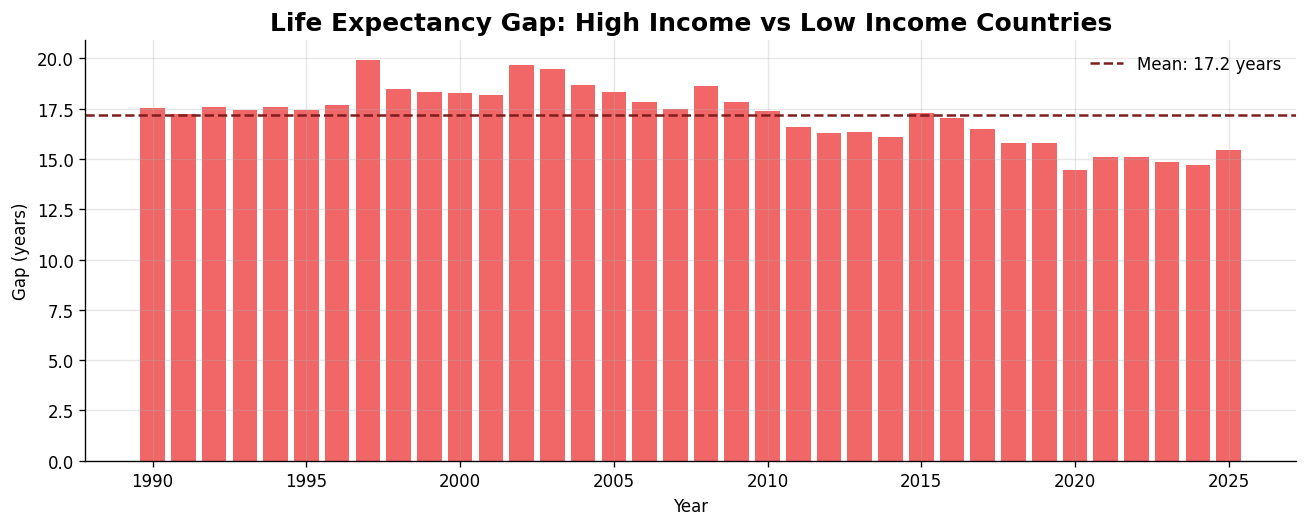

Gap range: 14.4 – 19.9 years
Peak: 19.9 years in 1997.0
Most recent (2025.0): 15.5 years


In [37]:
# Plotting the gap in life expectancy from 1990 to 2025 and comparing to the mean, used AI

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.bar(gap.index, gap.values, color='#EF4444', alpha=0.82, width=0.8)
ax.axhline(gap.mean(), color='#7F1D1D', linewidth=1.5, linestyle='--', 
           label=f'Mean: {gap.mean():.1f} years')

ax.set_title('Life Expectancy Gap: High Income vs Low Income Countries', fontsize=15, fontweight='bold')
ax.set_xlabel('Year'); ax.set_ylabel('Gap (years)')
ax.legend(frameon=False)
plt.tight_layout(); 
plt.savefig('Life_Expectancy_Gap.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Gap range: {gap.min():.1f} – {gap.max():.1f} years")
print(f"Peak: {gap.max():.1f} years in {gap.idxmax()}")
print(f"Most recent ({gap.index[-1]}): {gap.iloc[-1]:.1f} years")

In [38]:
# Measuring the average gni per income group from 1990 to 2025
ig_gni = df_clean.groupby(['income_group', 'year'])['gni'].mean().reset_index()
ig_gni

,income_group,year,gni
0,High Income,1990.0,31582.857143
1,High Income,1991.0,31062.162162
2,High Income,1992.0,32627.027027
3,High Income,1993.0,32223.684211
4,High Income,1994.0,33616.216216
...,...,...,...
139,Upper-Middle Income,2021.0,7408.400000
140,Upper-Middle Income,2022.0,7479.200000
141,Upper-Middle Income,2023.0,7579.230769
142,Upper-Middle Income,2024.0,7487.450980


In [39]:
y2025 = df_clean[df_clean.year == 2025].copy()
y2025

,country,year,population,life_expectancy,gni,income_group
42750,Afghanistan,2025.0,44500000.0,65.2,548.0,Low Income
42751,Angola,2025.0,38900000.0,67.1,2120.0,Lower-Middle Income
42752,Albania,2025.0,2820000.0,79.2,6390.0,Upper-Middle Income
42753,United Arab Emirates,2025.0,9670000.0,74.7,38700.0,High Income
42754,Argentina,2025.0,46300000.0,77.5,9880.0,Upper-Middle Income
...,...,...,...,...,...,...
42935,Samoa,2025.0,232000.0,71.2,3970.0,Lower-Middle Income
42936,Yemen,2025.0,36000000.0,68.4,969.0,Low Income
42937,South Africa,2025.0,61700000.0,66.5,6100.0,Upper-Middle Income
42938,Zambia,2025.0,21700000.0,64.7,1060.0,Low Income


In [40]:
#Finding the top life expectancy improvers
le_1990 = df_clean[df_clean.year==1990].set_index('country')['life_expectancy']
le_2025 = df_clean[df_clean.year==2025].set_index('country')['life_expectancy']
le_change = (le_2025 - le_1990).dropna().sort_values(ascending=False)
top10 = le_change.head(10)



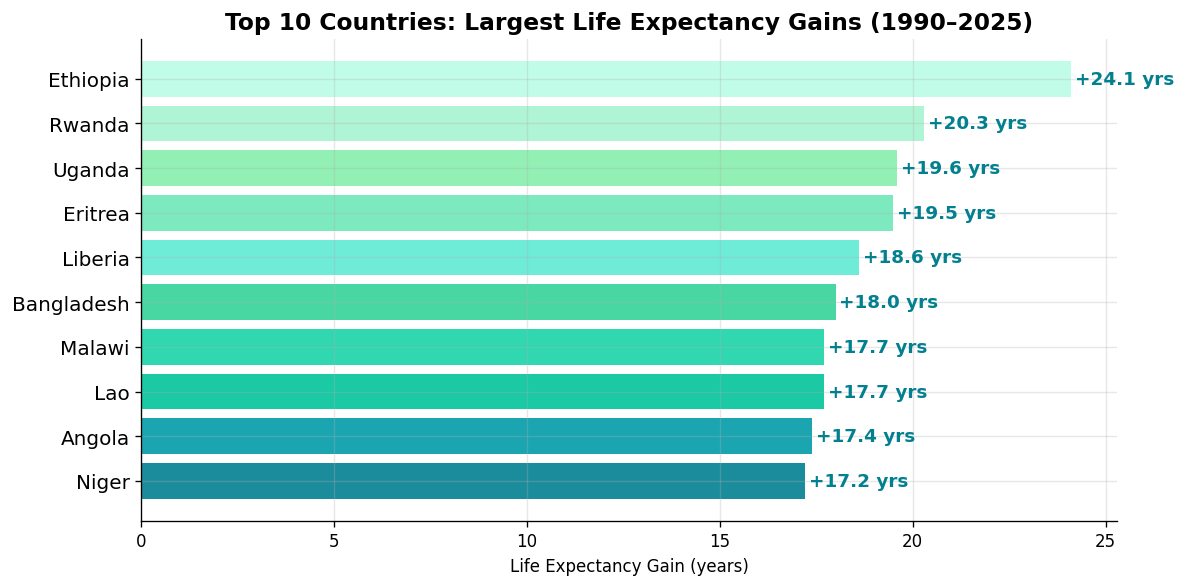

In [41]:
#Plotting the top life expectancy improvers, used AI

pal = ['#028090','#029BA8','#02C39A','#1AD4A7','#34D399',
       '#5EEAD4','#6EE7B7','#86EFAC','#A7F3D0','#BBFCE7']

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(range(len(top10)), top10.values[::-1], color=pal, alpha=0.9)
ax.set_yticks(range(len(top10)))
ax.set_yticklabels(top10.index[::-1], fontsize=12)
ax.set_xlabel('Life Expectancy Gain (years)')
ax.set_title('Top 10 Countries: Largest Life Expectancy Gains (1990–2025)', fontsize=14, fontweight='bold')
for i, v in enumerate(top10.values[::-1]):
    ax.text(v + 0.1, i, f'+{v:.1f} yrs', va='center', fontsize=11, color='#028090', fontweight='bold')
plt.tight_layout(); plt.show()



In [2]:
#Used AI for better visual clarity
# Comparing the highest life expectancy with the lower expectancy countries

import pandas as pd
import matplotlib.pyplot as plt

df_range = df_clean[(df_clean['year'] >= 2000) & (df_clean['year'] <= 2025)]

avg_data = df_range.groupby('country').agg({
    'life_expectancy': 'mean',
    'gni': 'mean'
}).reset_index()

top_5 = avg_data.nlargest(5, 'life_expectancy')
bottom_5 = avg_data.nsmallest(5, 'life_expectancy')
plot_data = pd.concat([top_5, bottom_5]).sort_values('life_expectancy')

plt.figure(figsize=(14, 8))
colors = ['#e74c3c']*5 + ['#27ae60']*5 
bars = plt.barh(plot_data['country'], plot_data['life_expectancy'], color=colors)

for bar, le, gni_val in zip(bars, plot_data['life_expectancy'], plot_data['gni']):
    gni_str = f"${int(gni_val):,}" if pd.notnull(gni_val) else "N/A"
    label = f' {le:.1f} yrs (GNI: {gni_str})'
    plt.text(bar.get_width(), bar.get_y() + bar.get_height()/2, label, 
             va='center', fontweight='bold', fontsize=11)

plt.title('Inequality Gap: Life Expectancy & GNI (2000-2025)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Average Life Expectancy (Years)', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.xlim(0, max(plot_data['life_expectancy']) * 1.35) 
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

NameError: name 'df_clean' is not defined

In [42]:
#Saving the dataset
df_clean.to_csv("WDS.csv", index=False)